In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect("data.db")

/home/cooldude/Desktop/Datamonk_Projects/data_eng/02_ETL_Pipeline_Indian_weather/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


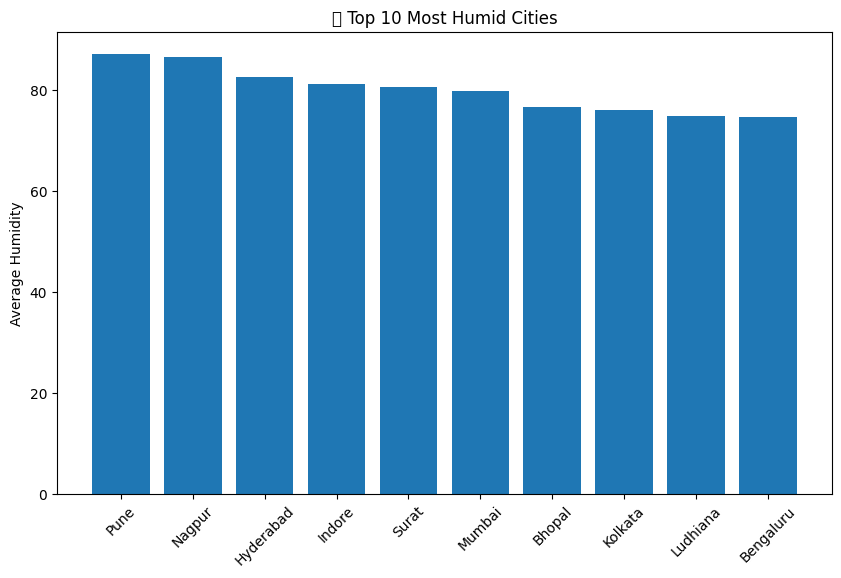

In [5]:
query = """
SELECT location_name, AVG(avg_humidity) AS avg_humidity
FROM daily_weather
GROUP BY location_name
ORDER BY avg_humidity DESC
LIMIT 10;
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10,6))
plt.bar(df["location_name"], df["avg_humidity"])
plt.xticks(rotation=45)
plt.ylabel("Average Humidity")
plt.title("🌍 Top 10 Most Humid Cities")
plt.show()


/home/cooldude/Desktop/Datamonk_Projects/data_eng/02_ETL_Pipeline_Indian_weather/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


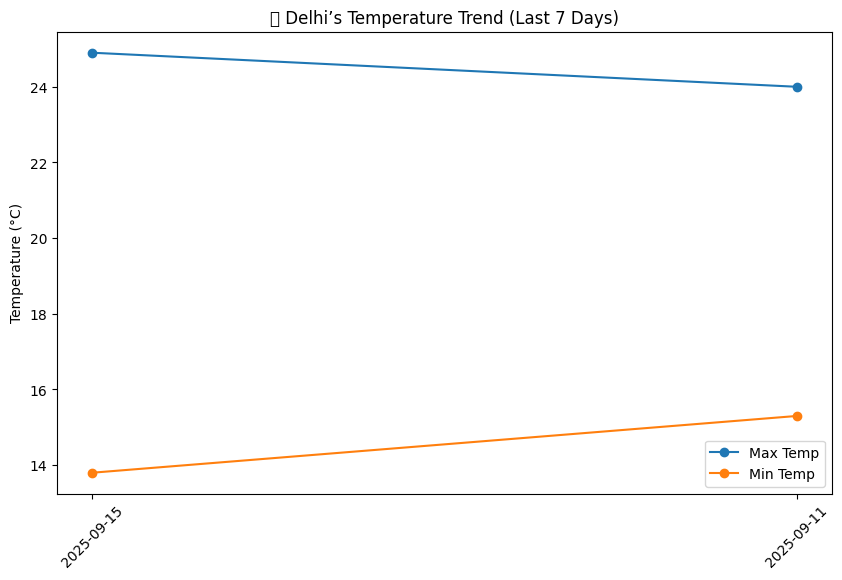

In [6]:
query = """
SELECT date, max_temp, min_temp
FROM daily_weather
WHERE location_name='Delhi'
ORDER BY date DESC
LIMIT 7;
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10,6))
plt.plot(df["date"], df["max_temp"], marker="o", label="Max Temp")
plt.plot(df["date"], df["min_temp"], marker="o", label="Min Temp")
plt.xticks(rotation=45)
plt.ylabel("Temperature (°C)")
plt.title("🌡 Delhi’s Temperature Trend (Last 7 Days)")
plt.legend()
plt.show()


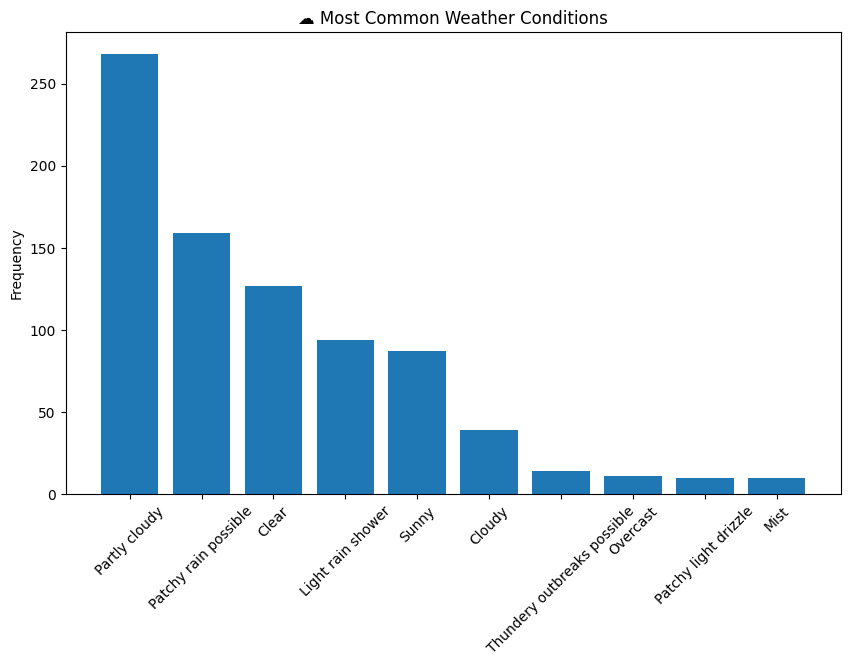

In [7]:
query = """
SELECT condition, COUNT(*) AS count
FROM weather
GROUP BY condition
ORDER BY count DESC
LIMIT 10;
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10,6))
plt.bar(df["condition"], df["count"])
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.title("☁️ Most Common Weather Conditions")
plt.show()


/home/cooldude/Desktop/Datamonk_Projects/data_eng/02_ETL_Pipeline_Indian_weather/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127750 (\N{CITYSCAPE AT DUSK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


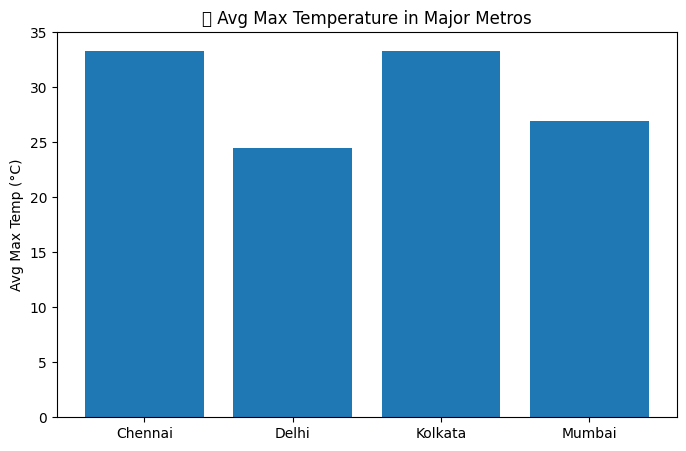

In [8]:
metros = ("Delhi","Mumbai","Bangalore","Chennai","Kolkata")
query = f"""
SELECT location_name, AVG(max_temp) AS avg_max_temp
FROM daily_weather
WHERE location_name IN {metros}
GROUP BY location_name;
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))
plt.bar(df["location_name"], df["avg_max_temp"])
plt.ylabel("Avg Max Temp (°C)")
plt.title("🌆 Avg Max Temperature in Major Metros")
plt.show()


/home/cooldude/Desktop/Datamonk_Projects/data_eng/02_ETL_Pipeline_Indian_weather/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


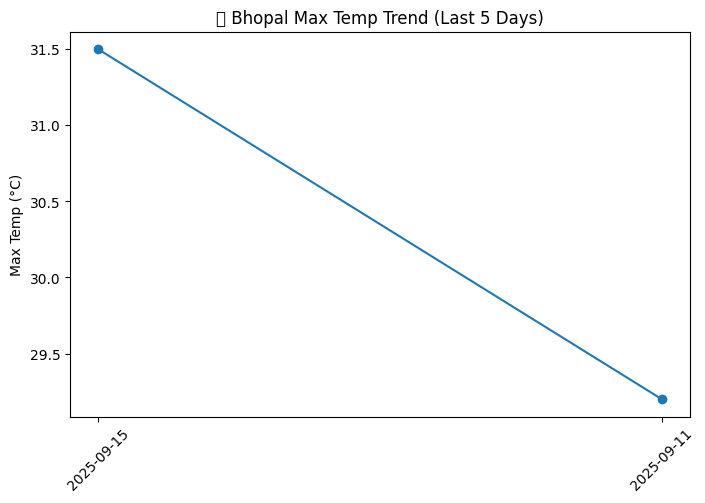

In [9]:
query = """
SELECT date, max_temp
FROM daily_weather
WHERE location_name='Bhopal'
ORDER BY date DESC
LIMIT 5;
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))
plt.plot(df["date"], df["max_temp"], marker="o")
plt.xticks(rotation=45)
plt.ylabel("Max Temp (°C)")
plt.title("📈 Bhopal Max Temp Trend (Last 5 Days)")
plt.show()


/home/cooldude/Desktop/Datamonk_Projects/data_eng/02_ETL_Pipeline_Indian_weather/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


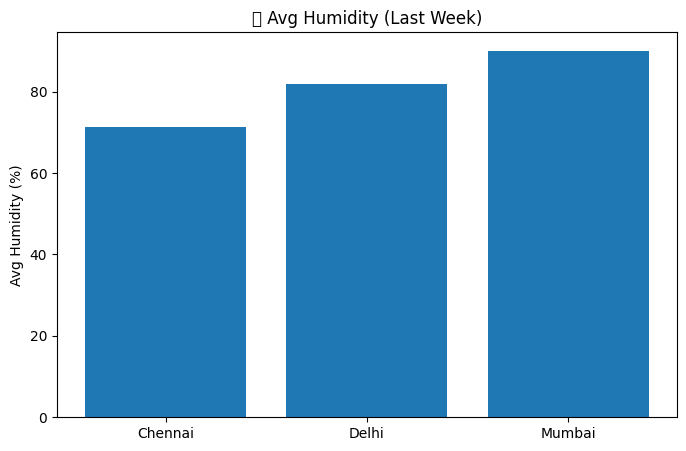

In [10]:
cities = ("Delhi","Mumbai","Chennai","Bangalore")
query = f"""
SELECT location_name, AVG(avg_humidity) AS avg_humidity
FROM daily_weather
WHERE location_name IN {cities}
  AND date >= DATE('now','-7 day')
GROUP BY location_name;
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))
plt.bar(df["location_name"], df["avg_humidity"])
plt.ylabel("Avg Humidity (%)")
plt.title("💧 Avg Humidity (Last Week)")
plt.show()


/home/cooldude/Desktop/Datamonk_Projects/data_eng/02_ETL_Pipeline_Indian_weather/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127774 (\N{SUN WITH FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cooldude/Desktop/Datamonk_Projects/data_eng/02_ETL_Pipeline_Indian_weather/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


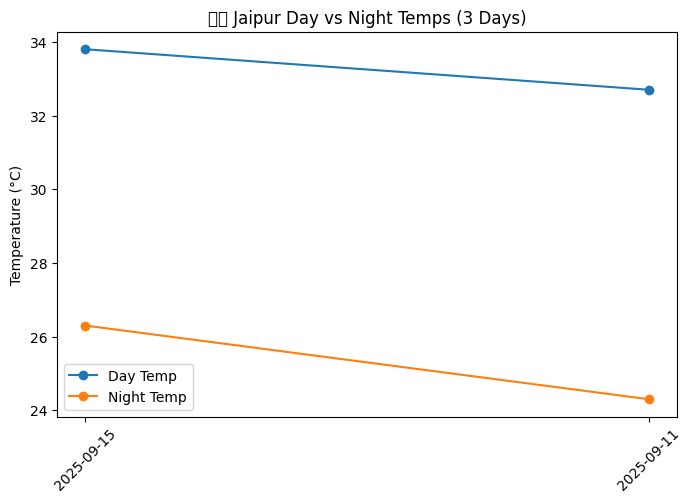

In [11]:
query = """
SELECT date, MAX(temperature) AS day_temp, MIN(temperature) AS night_temp
FROM weather
WHERE location_name='Jaipur'
GROUP BY date
ORDER BY date DESC
LIMIT 3;
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))
plt.plot(df["date"], df["day_temp"], marker="o", label="Day Temp")
plt.plot(df["date"], df["night_temp"], marker="o", label="Night Temp")
plt.xticks(rotation=45)
plt.ylabel("Temperature (°C)")
plt.title("🌞🌙 Jaipur Day vs Night Temps (3 Days)")
plt.legend()
plt.show()


/home/cooldude/Desktop/Datamonk_Projects/data_eng/02_ETL_Pipeline_Indian_weather/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


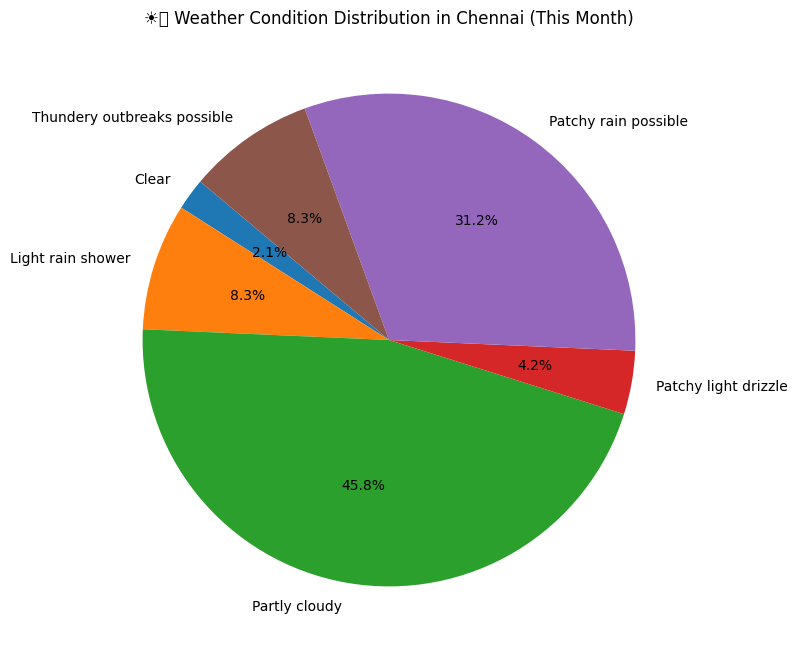

In [12]:
query = """
SELECT condition, COUNT(*) AS count
FROM weather
WHERE location_name='Chennai'
  AND strftime('%m', date) = strftime('%m', 'now')
GROUP BY condition;
"""
df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,8))
plt.pie(df["count"], labels=df["condition"], autopct="%1.1f%%", startangle=140)
plt.title("☀️🌧 Weather Condition Distribution in Chennai (This Month)")
plt.show()


In [13]:
conn.close()